# MoodRec — Emotion-Regulated Playlist Demo

This notebook is a self-contained demo of MoodRec. It generates playlists that gradually guide
a listener from their **current emotional state** to a **desired emotional state** using the
[iso principle](https://en.wikipedia.org/wiki/Iso_principle) from music therapy: start with
music that matches where the listener is, then shift step-by-step toward where they want to be.

Emotions are represented as points in a 2D space:
- **Valence** (0–1): unpleasant → pleasant
- **Energy** (0–1): calm/tired → alert/energized

**How to use this notebook:**
1. Run all cells in order
2. In **Step 1**, change the valence/energy variables to set your mood
3. Re-run from Step 1 onward to see an updated playlist and chart

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import re
import requests
import concurrent.futures

%matplotlib inline

---
## Part 1 — Core Recommender Algorithm

Three building blocks: generate emotional waypoints along a linear path, measure distance
between songs and waypoints, then assemble the playlist.

In [35]:
def generate_waypoints(current_valence, current_energy,
                        desired_valence, desired_energy,
                        n_steps=5):
    """Linearly interpolate n emotional targets from current to desired state."""
    valence_steps = np.linspace(current_valence, desired_valence, n_steps)
    energy_steps  = np.linspace(current_energy,  desired_energy,  n_steps)
    return list(zip(valence_steps, energy_steps))


def euclidean_distance(v1, e1, v2, e2):
    return np.sqrt((v1 - v2)**2 + (e1 - e2)**2)


def find_closest_song(df, target_valence, target_energy, exclude_indices=None):
    """Pick the nearest unselected song to a (valence, energy) target."""
    if exclude_indices is None:
        exclude_indices = []
    candidates = df[~df.index.isin(exclude_indices)].copy()
    candidates["distance"] = candidates.apply(
        lambda row: euclidean_distance(
            row["valence"], row["energy"],
            target_valence, target_energy
        ),
        axis=1
    )
    return candidates.nsmallest(1, "distance").iloc[0]


def build_playlist(df, current_valence, current_energy,
                   desired_valence, desired_energy, n_steps=5):
    """Assemble an iso-principle playlist across n waypoints."""
    waypoints = generate_waypoints(
        current_valence, current_energy,
        desired_valence, desired_energy,
        n_steps=n_steps
    )
    selected, used_indices = [], []
    for i, (target_v, target_e) in enumerate(waypoints):
        song = find_closest_song(df, target_v, target_e, exclude_indices=used_indices)
        used_indices.append(song.name)
        selected.append({
            "step": i + 1,
            "title": song.get("title", song.get("name", "Unknown")),
            "artist": song.get("artist", "Unknown"),
            "valence": round(song["valence"], 3),
            "energy": round(song["energy"], 3),
            "target_valence": round(target_v, 3),
            "target_energy": round(target_e, 3),
            "distance": round(song["distance"], 4),
        })
    return pd.DataFrame(selected)

---
## Part 2 — Song Library

A hardcoded dataset covering all four emotional quadrants. Swap `load_sample_data()` for
`pd.read_csv("data/songs.csv")` if you have a real library with `title`, `artist`,
`valence`, and `energy` columns.

In [36]:
df = pd.read_csv("MoodRec_Songs.csv")

# Rename to match the rest of the notebook
df = df.rename(columns={"Track Name": "title", "Artist Name(s)": "artist"})
df.columns = [c.lower().replace(" ", "_") for c in df.columns]

# Keep only the columns the notebook needs
keep = ["title", "artist", "valence", "energy",
        "danceability", "acousticness", "loudness", "tempo",
        "instrumentalness", "genres"]
df = df[keep].copy()

# Normalise tempo and loudness to [0, 1]
df["tempo_norm"]    = (df["tempo"]    - df["tempo"].min())    / (df["tempo"].max()    - df["tempo"].min())
df["loudness_norm"] = (df["loudness"] - df["loudness"].min()) / (df["loudness"].max() - df["loudness"].min())

df = df.reset_index(drop=True)

print(f"Loaded {len(df)} songs with {df.shape[1]} columns")
print(f"Genres populated: {df['genres'].notna().sum()} / {len(df)}")
df.head()


Loaded 367 songs with 12 columns
Genres populated: 238 / 367


,title,artist,valence,energy,danceability,acousticness,loudness,tempo,instrumentalness,genres,tempo_norm,loudness_norm
0,Existe Uma Voz,Rogê,0.895,0.738,0.770,0.2860,-6.686,90.553,0.801000,samba,0.205831,0.849727
1,Jazz (We've Got),A Tribe Called Quest,0.720,0.479,0.822,0.7190,-15.962,92.461,0.000044,"jazz rap,east coast hip hop,old school hip hop...",0.218739,0.490094
2,10% (feat. Kali Uchis),KAYTRANADA;Kali Uchis,0.615,0.757,0.794,0.0267,-6.644,107.990,0.000306,NaN,0.323792,0.851355
3,Sunday Bloody Sunday - Remastered 2008,U2,0.735,0.944,0.543,0.4020,-7.495,101.174,0.000564,rock,0.277682,0.818362
4,Donchano,Steve Lacy,0.772,0.489,0.674,0.6240,-7.257,207.947,0.001950,NaN,1.000000,0.827589


---
## Part 1b — Genre Tag Enrichment via LLM Scoring

We enrich each song with **semantic mood features** inferred from genre/mood tags:

1. **1b.1** — A hard-coded tag dictionary (28 songs × ~4 tags each)
2. **1b.2** — For each unique tag, ask `claude-sonnet-4-6` to score it on `valence_shift`,  
   `arousal_shift`, and an `emotions` dict; results are cached to `tag_scores_cache.json`
3. **1b.3** — Extended `find_closest_song` that optionally works in 4D  
   (audio features + normalised tag features), controlled by `tag_weight`
4. **1b.4** — Scatter plot of the library coloured by dominant discrete emotion

Two songs can sit at the same (valence, energy) point yet carry very different emotional  
textures (e.g. "euphoric" vs "nostalgic") — tag enrichment gives the recommender a way  
to distinguish them.

In [37]:
import json
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv()

OLLAMA_MODEL   = "llama3.2"  # change to any model you have pulled
LASTFM_API_KEY = os.environ.get("LASTFM_API_KEY", "")  # set in .env file

### 1b.1 — LLM Tag Generation

For each song in the library we ask a local Ollama model (`llama3.2` by default)
to generate 4–6 genre / mood tags using its knowledge of the track's title and artist.
Results are cached to `song_tags_cache.json` so re-runs are free.

No API key or cloud account needed — Ollama runs entirely on your machine.

In [38]:
SONG_TAGS_CACHE = "song_tags_cache.json"
LASTFM_WORKERS  = 5


def _load_song_tags_cache() -> dict:
    if os.path.exists(SONG_TAGS_CACHE):
        with open(SONG_TAGS_CACHE) as f:
            return json.load(f)
    return {}


def _save_song_tags_cache(cache: dict) -> None:
    with open(SONG_TAGS_CACHE, "w") as f:
        json.dump(cache, f, indent=2)


def _parse_json(text: str):
    """Strip markdown fences then parse JSON."""
    if "```" in text:
        parts = text.split("```")
        text = parts[1] if len(parts) >= 2 else parts[0]
        if text.startswith("json"):
            text = text[4:]
    return json.loads(text.strip())


def _clean_artist(artist: str) -> str:
    # CSV uses semicolons for collaborators — take only the primary artist
    primary = artist.split(";")[0].strip()
    return re.sub(r'\s+(ft\.?|feat\.?|featuring)\s+.*', '', primary, flags=re.IGNORECASE).strip()


def _lastfm_get(method: str, params: dict) -> list:
    resp = requests.get(
        "https://ws.audioscrobbler.com/2.0/",
        params={"method": method, "api_key": LASTFM_API_KEY,
                "format": "json", "autocorrect": 1, **params},
        timeout=10,
    )
    resp.raise_for_status()
    raw = resp.json().get("toptags", {}).get("tag", [])
    return [t["name"].lower() for t in raw[:6]]


def _fetch_tags_from_lastfm(title: str, artist: str) -> list:
    if not LASTFM_API_KEY:
        raise ValueError("LASTFM_API_KEY is empty — paste your key into cell 7.")
    clean = _clean_artist(artist)
    for query_artist in dict.fromkeys([clean, artist]):
        try:
            tags = _lastfm_get("track.gettoptags", {"track": title, "artist": query_artist})
            if tags:
                return tags
            tags = _lastfm_get("artist.gettoptags", {"artist": query_artist})
            if tags:
                return tags
        except Exception:
            pass
    return []


def _csv_genres(row) -> list:
    """Return cleaned genre list from the CSV Genres column, or [] if empty."""
    val = row.get("genres", None)
    if not val or (isinstance(val, float)):   # NaN comes through as float
        return []
    return [g.strip().lower() for g in str(val).split(",") if g.strip()]


def _merged_tags(row, song_tags_cache: dict) -> list:
    """Combine CSV genres with cached Last.fm tags for one song, deduplicated."""
    csv_tags    = _csv_genres(row)
    lastfm_tags = song_tags_cache.get(f"{row['title']}|||{row['artist']}", [])
    return list(dict.fromkeys(csv_tags + lastfm_tags))


def generate_all_tags(df) -> dict:
    """
    Combined tag sourcing with progress tracking.
    Every song's final tags = CSV Genres (if present) merged with Last.fm track/artist tags.
    Last.fm is called for every song not already present in song_tags_cache.json.
    """
    import time, threading
    cache    = _load_song_tags_cache()
    to_fetch = []

    for _, row in df.iterrows():
        cache_key = f"{row['title']}|||{row['artist']}"
        if cache_key not in cache:
            to_fetch.append((row["title"], row["artist"]))

    n_cached = len(df) - len(to_fetch)
    print(f"Tags: {len(df)} songs — "
          f"{n_cached} Last.fm tags already cached, "
          f"{len(to_fetch)} to fetch from Last.fm "
          f"(CSV Genres merged in for every song regardless)")

    if to_fetch:
        counter = {"done": 0}
        lock    = threading.Lock()
        t_start = time.time()

        def fetch_one(args):
            title, artist = args
            time.sleep(0.2)
            return title, artist, _fetch_tags_from_lastfm(title, artist)

        with concurrent.futures.ThreadPoolExecutor(max_workers=LASTFM_WORKERS) as ex:
            futures = {ex.submit(fetch_one, pair): pair for pair in to_fetch}
            for future in concurrent.futures.as_completed(futures):
                title, artist, tags = future.result()
                with lock:
                    counter["done"] += 1
                    done    = counter["done"]
                    elapsed = time.time() - t_start
                    eta     = (elapsed / done) * (len(to_fetch) - done)
                    status  = f"  [{done}/{len(to_fetch)}] {title}"
                    if eta > 0:
                        status += f"  (ETA {eta:.0f}s)"
                    print(status)
                if tags:
                    cache[f"{title}|||{artist}"] = tags
                else:
                    print(f"    ⚠️  no tags returned")
        _save_song_tags_cache(cache)
        print(f"  Last.fm done in {time.time() - t_start:.1f}s")

    result = {row["title"]: _merged_tags(row, cache) for _, row in df.iterrows()}
    return result


### 1b.2 — LLM Tag Scoring

For each **unique** tag across the library we ask `claude-sonnet-4-6` to return:

| Field | Range | Meaning |
|---|---|---|
| `valence_shift` | −1 → +1 | Pushes toward unpleasant (−) or pleasant (+) |
| `arousal_shift` | −1 → +1 | Pushes toward calm (−) or energised (+) |
| `emotions` | dict, 0–1 weights | Discrete emotion labels |

Scores are **cached** to `tag_scores_cache.json` — the API is only called once  
per unique tag. Per-track features are formed by **averaging** across all of a  
song's tags, then the three `top_emotions` are stored alongside a `dominant_emotion`.

In [39]:
CACHE_FILE  = "tag_scores_cache.json"
SCORE_BATCH = 10


def _load_cache() -> dict:
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}


def _save_cache(cache: dict) -> None:
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)


def _score_tag_single(tag: str, llm: ChatOllama, cache: dict) -> None:
    """Score one tag individually — fallback when batch parsing fails."""
    prompt = (
        f'Score the music genre/mood tag "{tag}" on three dimensions.\n'
        "Return ONLY valid JSON with exactly this structure (no extra text):\n"
        "{\n"
        '  "valence_shift": <float -1 to 1, negative=unpleasant, positive=pleasant>,\n'
        '  "arousal_shift": <float -1 to 1, negative=calm, positive=energised>,\n'
        '  "emotions": {"<label>": <weight 0-1>, ...}\n'
        "}\n"
        "Include 3-5 discrete emotion labels in the emotions dict."
    )
    try:
        result = _parse_json(llm.invoke(prompt).content)
        cache[tag] = result
        _save_cache(cache)
    except Exception:
        pass


def _score_tag_batch(tags: list, llm: ChatOllama, cache: dict) -> None:
    """Score a batch of tags in one Ollama call; falls back to per-tag on parse failure."""
    prompt = (
        "Score each of the following music genre/mood tags on three dimensions.\n"
        "Return ONLY a valid JSON object mapping each tag to its scores (no extra text):\n"
        "{\n"
        '  "<tag>": {"valence_shift": <-1 to 1>, "arousal_shift": <-1 to 1>, '
        '"emotions": {"<label>": <0-1>, ...}},\n'
        "  ...\n"
        "}\n"
        "Tags to score: " + json.dumps(tags) + "\n"
        "Include 3-5 emotion labels per tag."
    )
    try:
        results = _parse_json(llm.invoke(prompt).content)
        for tag in tags:
            if tag in results:
                cache[tag] = results[tag]
                _save_cache(cache)
    except Exception:
        print(f"    batch parse failed — retrying {len(tags)} tags individually...")
        for tag in tags:
            _score_tag_single(tag, llm, cache)


def aggregate_tag_scores(track_tags: dict, llm: ChatOllama) -> dict:
    """Score unique tags in batches via Ollama with ETA tracking."""
    import time
    cache       = _load_cache()
    unique_tags = sorted({t for tags in track_tags.values() for t in tags})
    to_score    = [t for t in unique_tags if t not in cache]
    n_cached    = len(unique_tags) - len(to_score)
    n_batches   = -(-len(to_score) // SCORE_BATCH)
    print(f"Ollama: {len(unique_tags)} unique tags — {n_cached} cached, "
          f"{len(to_score)} to score in {n_batches} batch{'es' if n_batches != 1 else ''}")

    t_start    = time.time()
    times      = []
    for i in range(0, len(to_score), SCORE_BATCH):
        batch    = to_score[i : i + SCORE_BATCH]
        b_num    = i // SCORE_BATCH + 1
        t_batch  = time.time()
        _score_tag_batch(batch, llm, cache)
        elapsed  = time.time() - t_batch
        times.append(elapsed)
        avg      = sum(times) / len(times)
        remaining = n_batches - b_num
        eta      = avg * remaining
        eta_str  = f"  ETA {eta:.0f}s" if remaining > 0 else "  done"
        print(f"  batch {b_num}/{n_batches} ({len(batch)} tags, {elapsed:.1f}s){eta_str}")

    if to_score:
        print(f"  scored {len(to_score)} tags in {time.time() - t_start:.1f}s total")

    track_agg = {}
    for title, tags in track_tags.items():
        scores = [cache[t] for t in tags if t in cache]
        if not scores:
            continue
        avg_val = float(np.mean([s["valence_shift"] for s in scores]))
        avg_aro = float(np.mean([s["arousal_shift"] for s in scores]))
        combined: dict = {}
        for s in scores:
            for emo, w in s.get("emotions", {}).items():
                combined[emo] = combined.get(emo, 0.0) + w
        for emo in combined:
            combined[emo] /= len(scores)
        top3     = sorted(combined.items(), key=lambda x: -x[1])[:3]
        dominant = top3[0][0] if top3 else "neutral"
        track_agg[title] = {
            "tag_valence_shift": avg_val,
            "tag_arousal_shift": avg_aro,
            "top_emotions":      top3,
            "dominant_emotion":  dominant,
        }
    return track_agg


In [40]:
GENRE_FIT_CACHE = "genre_fit_cache.json"


def _load_genre_cache() -> dict:
    if os.path.exists(GENRE_FIT_CACHE):
        with open(GENRE_FIT_CACHE) as f:
            return json.load(f)
    return {}


def _save_genre_cache(cache: dict) -> None:
    with open(GENRE_FIT_CACHE, "w") as f:
        json.dump(cache, f, indent=2)


def score_genre_fit(title: str, artist: str, genre_request: str,
                    llm, cache: dict, known_tags: list = None) -> float:
    """Score 0–1 how well a song fits a free-text genre/mood request."""
    key = f"{title}|||{artist}|||{genre_request}"
    if key in cache:
        return cache[key]

    tag_context = (
        f'Known tags/genres for this song: {", ".join(known_tags)}.\n'
        if known_tags else ""
    )
    prompt = (
        f'How well does "{title}" by {artist} fit the genre/mood "{genre_request}"?\n'
        f"{tag_context}"
        "Return ONLY a single float between 0.0 (no fit) and 1.0 (perfect fit). No other text."
    )
    response = llm.invoke(prompt)
    try:
        score = float(response.content.strip())
        score = max(0.0, min(1.0, score))
    except ValueError:
        score = 0.5

    cache[key] = score
    _save_genre_cache(cache)
    return score


def score_all_genre_fits(df, genre_request: str, llm):
    """Add/update genre_fit column in df for the given genre_request, grounded in known song tags."""
    if not genre_request:
        df["genre_fit"] = 1.0
        return df

    cache           = _load_genre_cache()
    song_tags_cache = _load_song_tags_cache()
    n_cached = sum(
        f"{r['title']}|||{r['artist']}|||{genre_request}" in cache
        for _, r in df.iterrows()
    )
    print(f"Scoring genre fit for '{genre_request}': "
          f"{n_cached}/{len(df)} cached, {len(df) - n_cached} to fetch...")

    df["genre_fit"] = [
        score_genre_fit(
            row["title"], row["artist"], genre_request, llm, cache,
            known_tags=_merged_tags(row, song_tags_cache),
        )
        for _, row in df.iterrows()
    ]
    return df


In [41]:
# Spin up the local Ollama model (still used for tag scoring and genre fit)
llm = ChatOllama(model=OLLAMA_MODEL, temperature=0)

# Step 1: fetch genre/mood tags from Last.fm for every song
track_tags = generate_all_tags(df)

# Step 2: score each unique tag via Ollama and compute per-track aggregates
track_agg = aggregate_tag_scores(track_tags, llm)

# Merge enriched columns back into the main df
df["tag_valence_shift"] = df["title"].map(
    lambda t: track_agg.get(t, {}).get("tag_valence_shift", 0.0)
)
df["tag_arousal_shift"] = df["title"].map(
    lambda t: track_agg.get(t, {}).get("tag_arousal_shift", 0.0)
)
df["top_emotions"] = df["title"].map(
    lambda t: track_agg.get(t, {}).get("top_emotions", [])
)
df["dominant_emotion"] = df["title"].map(
    lambda t: track_agg.get(t, {}).get("dominant_emotion", "neutral")
)

print(f"\ndf now has {df.shape[1]} columns: {list(df.columns)}")
df[["title", "valence", "energy",
    "tag_valence_shift", "tag_arousal_shift", "dominant_emotion"]].round(3)


Tags: 367 songs — 362 Last.fm tags already cached, 5 to fetch from Last.fm (CSV Genres merged in for every song regardless)
  [1/5] say you're fine  (ETA 2s)
    ⚠️  no tags returned
  [2/5] Don't Tell Me  (ETA 1s)
    ⚠️  no tags returned
  [3/5] My Child  (ETA 0s)
    ⚠️  no tags returned
  [4/5] RINSE  (ETA 0s)
    ⚠️  no tags returned
  [5/5] Take My Sense
    ⚠️  no tags returned
  Last.fm done in 0.8s
Ollama: 494 unique tags — 494 cached, 0 to score in 0 batches

df now has 16 columns: ['title', 'artist', 'valence', 'energy', 'danceability', 'acousticness', 'loudness', 'tempo', 'instrumentalness', 'genres', 'tempo_norm', 'loudness_norm', 'tag_valence_shift', 'tag_arousal_shift', 'top_emotions', 'dominant_emotion']


,title,valence,energy,tag_valence_shift,tag_arousal_shift,dominant_emotion
0,Existe Uma Voz,0.895,0.738,0.542,-0.208,Joy
1,Jazz (We've Got),0.720,0.479,0.117,0.450,energetic
2,10% (feat. Kali Uchis),0.615,0.757,-0.067,0.450,playfulness
3,Sunday Bloody Sunday - Remastered 2008,0.735,0.944,0.167,0.183,energetic
4,Donchano,0.772,0.489,0.300,-0.200,soothing
...,...,...,...,...,...,...
362,Yellow,0.285,0.661,-0.033,0.017,energetic
363,Unwritten,0.629,0.800,0.158,0.175,excitement
364,What You Won't Do for Love,0.797,0.396,0.229,0.143,sophisticated
365,Skinny Love,0.109,0.263,0.217,0.100,serenity


### 1b.3 — Extended `find_closest_song`

The function supports three optional distance dimensions on top of core valence/energy:

**Tag features** (`use_tag_features=True`, `tag_weight=0.3`)  
Adds the LLM-inferred `tag_valence_shift` and `tag_arousal_shift` as extra dimensions.

**Genre fit** (`genre_request`, `genre_weight=0.4`)  
Penalises songs whose Ollama genre-fit score is low for the user's stated preference.

**Extended audio features** (`use_audio_features=True`, `audio_feature_weight=0.2`)  
Derives targets for four Spotify audio features from the emotional waypoint:

| Feature | Target derivation | Rationale |
|---|---|---|
| `acousticness` | `1 − target_energy` | High-energy waypoints call for electric/produced sound; calm waypoints suit acoustic instruments |
| `danceability` | `target_valence` | Pleasant, positive emotions map naturally to rhythmic, danceable tracks |
| `tempo_norm` | `target_energy` | Faster tempos align with energised states; slower with calm or tired states |
| `loudness_norm` | `target_energy` | Louder mixes reinforce high-energy waypoints; quieter ones suit low-energy states |

All three dimensions are additive — any combination can be enabled independently.


In [42]:
def find_closest_song(df, target_valence, target_energy, exclude_indices=None,
                      use_tag_features=True,    tag_weight=0.3,
                      genre_request=None,         genre_weight=0.4,
                      use_audio_features=True,   audio_feature_weight=0.2,
                      prev_valence=None,           prev_energy=None,
                      journey_dv=0,               journey_de=0,
                      backtrack_tolerance=0.05,  overshoot_tolerance=0.1,
                      shortlist_size=15):
    """Pick the nearest unselected song to a (valence, energy) target.

    Optional distance dimensions:
      use_tag_features    — adds LLM tag valence/arousal shifts
      genre_request       — penalises songs with low genre-fit scores
      use_audio_features  — adds acousticness, danceability, tempo_norm, loudness_norm
      prev_valence/energy + journey_dv/de — hard-filters candidates that move backward
          or overshoot past the current target waypoint
          journey_dv/de are the GLOBAL direction signs (+1/-1/0), fixed for the whole trip
      shortlist_size — only the N closest-by-raw-distance candidates are eligible
          for tag/genre/audio re-ranking, so those weights can't pull in a song
          that's actually far from the target waypoint
    """
    if exclude_indices is None:
        exclude_indices = []
    candidates = df[~df.index.isin(exclude_indices)].copy()

    # Hard directional filter using the global journey direction (never flip)
    if prev_valence is not None and prev_energy is not None:
        filtered = candidates.copy()
        if journey_dv > 0:
            filtered = filtered[filtered["valence"] >= prev_valence - backtrack_tolerance]
            filtered = filtered[filtered["valence"] <= target_valence + overshoot_tolerance]
        elif journey_dv < 0:
            filtered = filtered[filtered["valence"] <= prev_valence + backtrack_tolerance]
            filtered = filtered[filtered["valence"] >= target_valence - overshoot_tolerance]
        if journey_de > 0:
            filtered = filtered[filtered["energy"] >= prev_energy - backtrack_tolerance]
            filtered = filtered[filtered["energy"] <= target_energy + overshoot_tolerance]
        elif journey_de < 0:
            filtered = filtered[filtered["energy"] <= prev_energy + backtrack_tolerance]
            filtered = filtered[filtered["energy"] >= target_energy - overshoot_tolerance]
        if len(filtered) >= 1:
            candidates = filtered

    core_dist = (
        (candidates["valence"] - target_valence) ** 2
        + (candidates["energy"]  - target_energy)  ** 2
    )

    # Shortlist by raw proximity to the target first, so tag/genre/audio
    # weighting can only break ties among songs that are actually close to
    # the target waypoint — not pull in a distant song that happens to be
    # a great mood/genre match.
    shortlist_n = min(shortlist_size, len(candidates))
    shortlist_idx = core_dist.nsmallest(shortlist_n).index
    candidates = candidates.loc[shortlist_idx]
    dist = core_dist.loc[shortlist_idx]

    if use_tag_features and "tag_valence_shift" in df.columns:
        tv_norm = (candidates["tag_valence_shift"] + 1) / 2
        ta_norm = (candidates["tag_arousal_shift"] + 1) / 2
        dist += tag_weight * (
            (tv_norm - target_valence) ** 2
            + (ta_norm - target_energy)  ** 2
        )

    if genre_request and "genre_fit" in df.columns:
        dist += genre_weight * (1 - candidates["genre_fit"]) ** 2

    if use_audio_features and all(
        c in df.columns for c in ["acousticness", "danceability", "tempo_norm", "loudness_norm"]
    ):
        acousticness_target = 1 - target_energy
        danceability_target = target_valence
        tempo_target        = target_energy
        loudness_target     = target_energy
        dist += audio_feature_weight * (
            (candidates["acousticness"]   - acousticness_target) ** 2
            + (candidates["danceability"] - danceability_target) ** 2
            + (candidates["tempo_norm"]   - tempo_target)        ** 2
            + (candidates["loudness_norm"]- loudness_target)     ** 2
        )

    candidates["distance"] = np.sqrt(dist)
    return candidates.nsmallest(1, "distance").iloc[0]


print("find_closest_song ready (global-direction hard filter).")


find_closest_song ready (global-direction hard filter).


In [43]:
def build_playlist(df, current_valence, current_energy,
                   desired_valence, desired_energy, n_steps=5,
                   genre_request=None,       genre_weight=0.4,
                   use_audio_features=True,  audio_feature_weight=0.2,
                   use_tag_features=True,    tag_weight=0.3,
                   backtrack_tolerance=0.05, overshoot_tolerance=0.1,
                   shortlist_size=15):
    """Iso-principle playlist with optional genre preference and audio feature matching."""
    waypoints = generate_waypoints(
        current_valence, current_energy,
        desired_valence, desired_energy, n_steps=n_steps
    )
    journey_dv = int(np.sign(desired_valence - current_valence))
    journey_de = int(np.sign(desired_energy  - current_energy))

    selected, used_indices = [], []
    prev_v, prev_e = current_valence, current_energy

    for i, (target_v, target_e) in enumerate(waypoints):
        song = find_closest_song(
            df, target_v, target_e,
            exclude_indices=used_indices,
            use_tag_features=use_tag_features,
            tag_weight=tag_weight,
            genre_request=genre_request,
            genre_weight=genre_weight,
            use_audio_features=use_audio_features,
            audio_feature_weight=audio_feature_weight,
            prev_valence=prev_v,
            prev_energy=prev_e,
            journey_dv=journey_dv,
            journey_de=journey_de,
            backtrack_tolerance=backtrack_tolerance,
            overshoot_tolerance=overshoot_tolerance,
            shortlist_size=shortlist_size,
        )
        used_indices.append(song.name)
        prev_v = song["valence"]
        prev_e = song["energy"]
        selected.append({
            "step":           i + 1,
            "title":          song.get("title",  "Unknown"),
            "artist":         song.get("artist", "Unknown"),
            "valence":        round(song["valence"], 3),
            "energy":         round(song["energy"],  3),
            "genre_fit":      round(song.get("genre_fit", 1.0), 3),
            "target_valence": round(target_v, 3),
            "target_energy":  round(target_e, 3),
            "distance":       round(song["distance"], 4),
        })
    return pd.DataFrame(selected)


print("build_playlist ready (tag + audio features enabled by default).")


build_playlist ready (tag + audio features enabled by default).


### 1b.4 — Emotion-Coloured Scatter Plot

Each point is one song, positioned by its **valence** (x) and **energy** (y) audio features.  
Colour encodes the **dominant discrete emotion** derived from the LLM tag scores,  
making it easy to see where e.g. "nostalgia" or "anger" cluster in the 2D space.

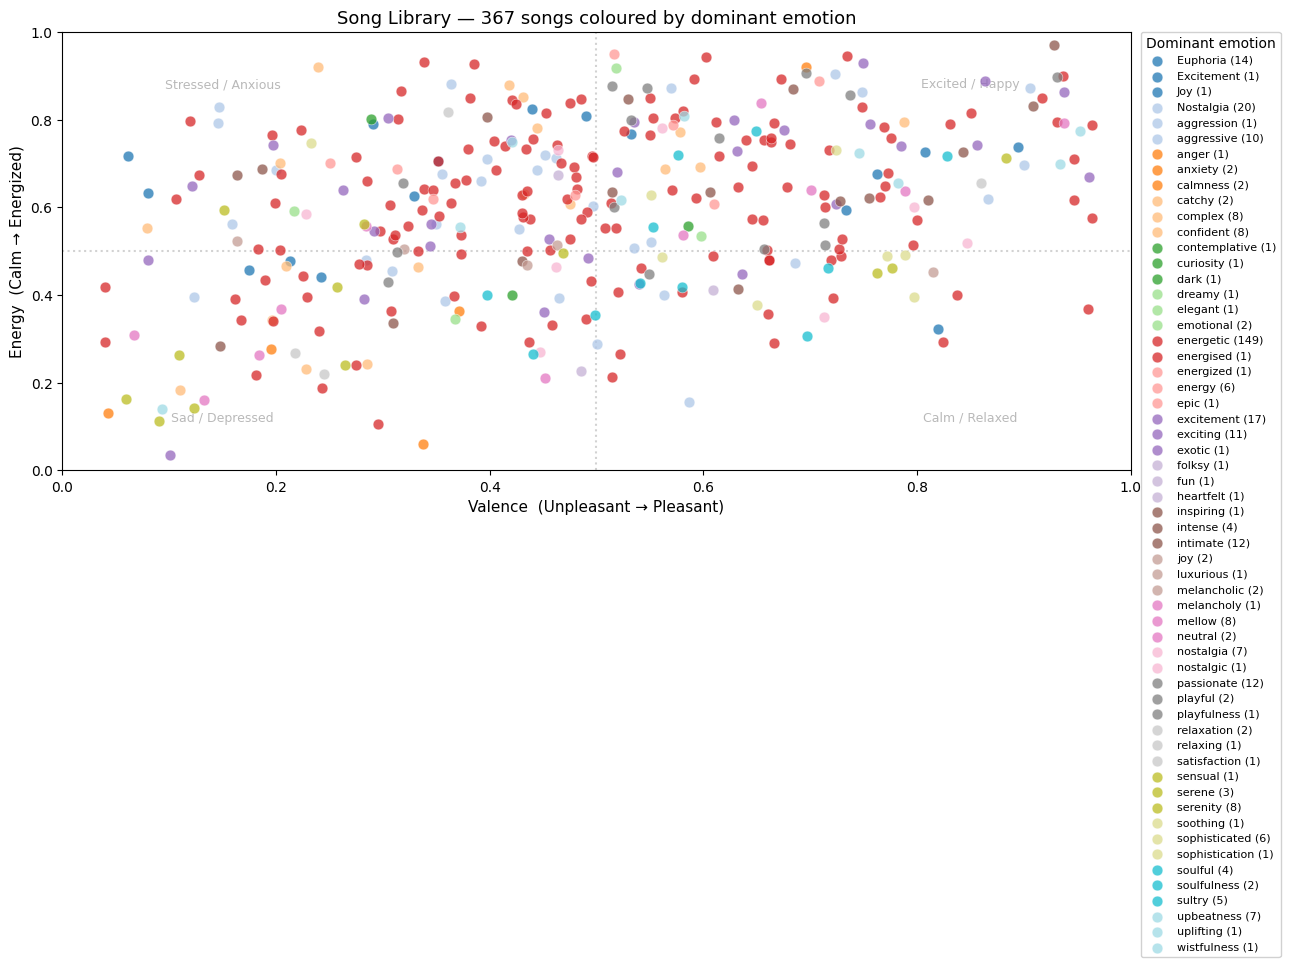

In [44]:
emotions  = sorted(df["dominant_emotion"].unique())
cmap      = plt.colormaps["tab20"].resampled(max(len(emotions), 1))
color_map = {emo: cmap(i) for i, emo in enumerate(emotions)}

fig, ax = plt.subplots(figsize=(13, 8))

for emo, grp in df.groupby("dominant_emotion"):
    ax.scatter(
        grp["valence"], grp["energy"],
        s=60, color=color_map[emo], label=f"{emo} ({len(grp)})",
        zorder=5, alpha=0.75, edgecolors="white", linewidths=0.4,
    )

# Quadrant labels
for x, y, label in [
    (0.15, 0.88, "Stressed / Anxious"),
    (0.85, 0.88, "Excited / Happy"),
    (0.15, 0.12, "Sad / Depressed"),
    (0.85, 0.12, "Calm / Relaxed"),
]:
    ax.text(x, y, label, ha="center", va="center",
            fontsize=9, color="gray", alpha=0.55,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.5, ec="none"))

ax.axvline(0.5, linestyle=":", color="gray", alpha=0.35)
ax.axhline(0.5, linestyle=":", color="gray", alpha=0.35)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Valence  (Unpleasant → Pleasant)", fontsize=11)
ax.set_ylabel("Energy  (Calm → Energized)", fontsize=11)
ax.set_title(f"Song Library — {len(df)} songs coloured by dominant emotion", fontsize=13)
ax.legend(title="Dominant emotion", loc="upper left", fontsize=8,
          bbox_to_anchor=(1.01, 1), borderaxespad=0, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Step 1 — How Are You Feeling?

Set your **current** and **desired** emotional state by editing the four variables below,
then re-run this cell and everything below it.

| Axis | Low (0.0) | High (1.0) |
|---|---|---|
| **Valence** | Unpleasant | Pleasant |
| **Energy** | Calm / Tired | Alert / Energized |

In [45]:
# --- Edit these values to set your mood and genre preference ---
current_valence = 0.23  # how pleasant you feel right now  (0=unpleasant, 1=pleasant)
current_energy  = 0.1   # how energized you feel right now (0=calm, 1=energized)

desired_valence = 0.75  # how pleasant you want to feel
desired_energy  = 0.82  # how energized you want to feel

# One genre/mood, multiple, or empty list for no preference
# e.g. ["indie folk"]  or  ["jazz", "soul"]  or  []
genre_preferences = ["rock"]
# ---------------------------------------------------------------

def label_quadrant(v, e):
    if v < 0.5 and e > 0.5:
        return "Activated / Unpleasant  (e.g. stressed, anxious, angry)"
    elif v >= 0.5 and e > 0.5:
        return "Activated / Pleasant    (e.g. excited, happy, energized)"
    elif v < 0.5 and e <= 0.5:
        return "Deactivated / Unpleasant (e.g. sad, depressed, bored)"
    else:
        return "Deactivated / Pleasant   (e.g. calm, relaxed, serene)"

print(f"You are feeling:  {label_quadrant(current_valence, current_energy)}")
print(f"You want to feel: {label_quadrant(desired_valence, desired_energy)}")
if genre_preferences:
    print(f"Genre preference: {' + '.join(genre_preferences)}")


You are feeling:  Deactivated / Unpleasant (e.g. sad, depressed, bored)
You want to feel: Activated / Pleasant    (e.g. excited, happy, energized)
Genre preference: rock


---
## Step 2 — Your Emotion-Regulated Playlist

Each song is chosen to sit as close as possible to the next emotional waypoint along the path
from your current state to your desired state.

In [46]:
# Score genre fit — handles one genre, multiple genres, or none
if genre_preferences:
    genre_scores = []
    for genre in genre_preferences:
        df = score_all_genre_fits(df, genre, llm)
        genre_scores.append(df["genre_fit"].values.copy())
    # Average across all requested genres
    df["genre_fit"] = np.mean(genre_scores, axis=0)
    genre_label = " + ".join(genre_preferences)
    top = df[["title", "genre_fit"]].sort_values("genre_fit", ascending=False)
    print(f"\nTop matches for '{genre_label}':")
    print(top.head(8).to_string(index=False))
else:
    genre_label = None

n_steps = 10
playlist = build_playlist(
    df, current_valence, current_energy,
    desired_valence, desired_energy, n_steps=n_steps,
    genre_request=genre_label,
)

print(f"\nYour {n_steps}-Song Journey\n" + "-" * 40)
for _, row in playlist.iterrows():
    fit = f"  genre fit: {row['genre_fit']:.2f}" if genre_label else ""
    print(f"  {int(row['step'])}.  {row['title']} — {row['artist']}{fit}")
    print(f"      valence: {row['valence']}  energy: {row['energy']}\n")

playlist


Scoring genre fit for 'rock': 367/367 cached, 0 to fetch...

Top matches for 'rock':
                                title  genre_fit
Since I've Been Loving You - Remaster       0.95
        Stairway to Heaven - Remaster       0.95
                Sunshine Of Your Love       0.95
     Champagne Supernova (Remastered)       0.90
                             Everlong       0.90
                         Thunder Road       0.90
        New Person, Same Old Mistakes       0.85
            Free As A Bird - 1995 Mix       0.85

Your 10-Song Journey
----------------------------------------
  1.  Something - Studio Demo — The Beatles  genre fit: 0.80
      valence: 0.243  energy: 0.187

  2.  Exit Music (For A Film) — Radiohead  genre fit: 0.83
      valence: 0.195  energy: 0.276

  3.  Stairway to Heaven - Remaster — Led Zeppelin  genre fit: 0.95
      valence: 0.197  energy: 0.34

  4.  Country Girl — Crosby, Stills, Nash & Young  genre fit: 0.85
      valence: 0.367  energy: 0.398

  5.  Dre

,step,title,artist,valence,energy,genre_fit,target_valence,target_energy,distance
0,1,Something - Studio Demo,The Beatles,0.243,0.187,0.80,0.230,0.10,0.4430
1,2,Exit Music (For A Film),Radiohead,0.195,0.276,0.83,0.288,0.18,0.4584
2,3,Stairway to Heaven - Remaster,Led Zeppelin,0.197,0.340,0.95,0.346,0.26,0.3517
3,4,Country Girl,"Crosby, Stills, Nash & Young",0.367,0.398,0.85,0.403,0.34,0.2247
4,5,Dreams,Allman Brothers Band,0.540,0.426,0.85,0.461,0.42,0.1968
5,6,The Weight - Remastered 2000,The Band,0.518,0.552,0.85,0.519,0.50,0.1791
6,7,RINSE,Rugby Wild,0.581,0.536,0.83,0.577,0.58,0.1920
7,8,California Jam,Klaatu,0.713,0.628,0.85,0.634,0.66,0.2003
8,9,Baby I'm a Star,Prince,0.676,0.776,0.85,0.692,0.74,0.2017
9,10,25 or 6 to 4 - 2002 Remaster,Chicago,0.723,0.905,0.85,0.750,0.82,0.2632


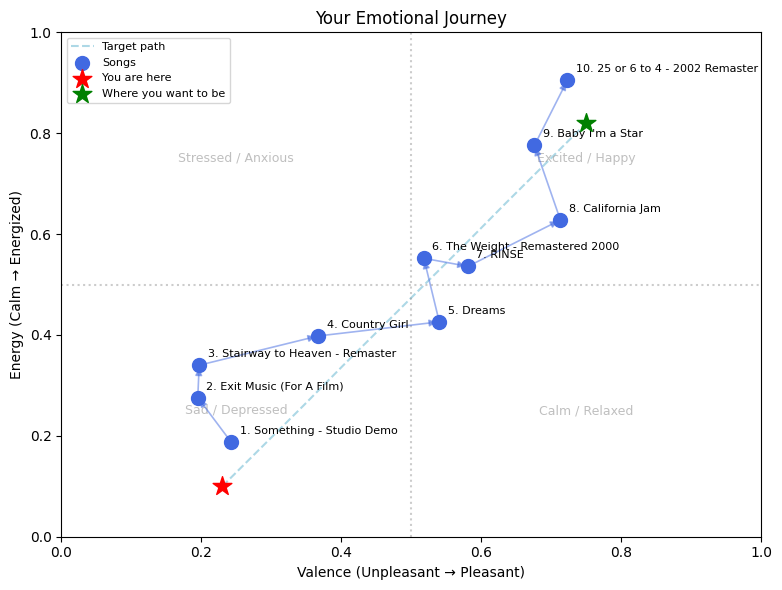

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

# Quadrant labels
for x, y, label in [
    (0.25, 0.75, "Stressed / Anxious"),
    (0.75, 0.75, "Excited / Happy"),
    (0.25, 0.25, "Sad / Depressed"),
    (0.75, 0.25, "Calm / Relaxed"),
]:
    ax.text(x, y, label, ha="center", va="center", fontsize=9, color="gray", alpha=0.5)

# Dashed target path
ax.plot(playlist["target_valence"], playlist["target_energy"],
        linestyle="--", color="lightblue", linewidth=1.5, label="Target path", zorder=2)

# Arrows connecting songs in step order
for i in range(len(playlist) - 1):
    x0, y0 = playlist.iloc[i]["valence"],   playlist.iloc[i]["energy"]
    x1, y1 = playlist.iloc[i+1]["valence"], playlist.iloc[i+1]["energy"]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="royalblue",
                                lw=1.2, alpha=0.5))

# Song positions
ax.scatter(playlist["valence"], playlist["energy"],
           s=100, color="royalblue", zorder=5, label="Songs")
for _, row in playlist.iterrows():
    ax.annotate(f"{int(row['step'])}. {row['title']}",
                (row["valence"], row["energy"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

# Start / end markers
ax.scatter([current_valence], [current_energy],
           s=200, color="red", marker="*", zorder=6, label="You are here")
ax.scatter([desired_valence], [desired_energy],
           s=200, color="green", marker="*", zorder=6, label="Where you want to be")

ax.axvline(0.5, linestyle=":", color="gray", alpha=0.4)
ax.axhline(0.5, linestyle=":", color="gray", alpha=0.4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Valence (Unpleasant → Pleasant)")
ax.set_ylabel("Energy (Calm → Energized)")
ax.set_title("Your Emotional Journey")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
